In [1]:
import geopandas as gpd
import geonamescache
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor
import numpy as np
from numpy.random import choice
import random
import datetime
from shapely import Point
from datetime import datetime, timedelta

import warnings


In [2]:
SHAPEFILE = "/home/mohamed/Mohamed/Vodafone_project/all_egypt_map_shpfile/shp_output_names/Shyakha_Village/Shyakha_Village.shp"

In [3]:

def get_unknown_eg_areas_locations(area_gdf):
    # Read The area geodataframe

    centroids = area_gdf.centroid

    unkown_areas_locations = np.array([[cent.x, cent.y] for cent in centroids])

    return unkown_areas_locations


def get_known_eg_cities_df():
    gc = geonamescache.GeonamesCache()
    cities = gc.get_cities()
    cities_df = pd.DataFrame.from_dict(cities)
    cities_df = cities_df.transpose()
    cities_df = cities_df.drop(columns=["alternatenames", "admin1code"])
    cities_df = cities_df[cities_df["countrycode"] == "EG"]

    return cities_df


def get_trained_knn_model(known_pop_cities_df):
    x_train = np.vstack(
        [
            known_pop_cities_df["latitude"].values,
            known_pop_cities_df["longitude"].values,
        ]
    ).T
    y_train = known_pop_cities_df["population"].values
    knn_model = KNeighborsRegressor()
    knn_model.fit(x_train, y_train)

    return knn_model


def estimate_population(knn_model, unknown_pop_eg_areas):
    return knn_model.predict(unknown_pop_eg_areas)



In [4]:
# Get cities with know populations
known_pop_eg_cities = get_known_eg_cities_df()

# Get the train knn model for estimation
knn_model = get_trained_knn_model(known_pop_eg_cities)

# Get the centroid (location) of each polygon (area. e.g. (city, Village)),
# To estimite their population.
areas_gdf = gpd.GeoDataFrame.from_file(SHAPEFILE)
unknown_pop_eg_areas = get_unknown_eg_areas_locations(areas_gdf)

# Predict unkown areas population
estimated_popualtion = (
    np.array(estimate_population(knn_model, unknown_pop_eg_areas), dtype=float) 
)

/tmp/ipykernel_6589/986730145.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = area_gdf.centroid


In [5]:
areas_gdf["population"] = estimated_popualtion
areas_gdf["population_density"] = areas_gdf["population"] /areas_gdf["SHAPE_Area"]

In [6]:
areas_gdf 

,GOV_CODE,SEC_CODE,SSEC_CODE,SHAPE_Leng,SHAPE_Area,GOV_NAME_E,GOV_NAME_A,SEC_NAME_E,SEC_NAME_A,SSEC_NAME_,SSEC_NAM_1,geometry,population,population_density
0,28,2808,280801,12547.889894,9.361281e+06,Aswan Governorate,محافظه اسوان,New Aswan City,اسوان الجديده,mdynt aswan aljdyda,مدينة أسوان الجديدة,"POLYGON ((32.86417 24.18292, 32.86442 24.18183...",1154596.6,0.123337
1,16,1607,160754,15185.387468,9.865280e+06,Gharbiya Governorate,محافظة الغربية,El-Mahalla El-Kubra,مركز المحله الكبرى,nmrt albsl,نمرة البصل,"POLYGON ((31.06371 31.06602, 31.06613 31.06578...",182352.4,0.018484
2,17,1705,170525,7924.332176,2.336633e+06,Menoufia Governorate,محافظة المنوفية,Martyrs Center,مركز الشهداء,kfr dnshway,كفر دنشواي,"POLYGON ((30.85010 30.58893, 30.85025 30.58548...",104918.4,0.044902
3,17,1711,171107,10282.252994,3.386741e+06,Menoufia Governorate,محافظة المنوفية,Sadat City and Center,مركز السادات,kfr daod,كفر داود,"MULTIPOLYGON (((30.83658 30.47675, 30.83655 30...",104399.6,0.030826
4,17,1711,171103,15694.908721,5.659568e+06,Menoufia Governorate,محافظة المنوفية,Sadat City and Center,مركز السادات,altrana,الطرانة,"MULTIPOLYGON (((30.83929 30.44366, 30.83932 30...",104399.6,0.018447
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5612,15,1501,150106,4814.622605,1.205519e+06,Kafr El-Sheikh Governorate,محافظه كفر الشيخ,Kafr El-Sheikh,قسم كفر الشيخ,aly mstfy alzwaoy,على مصطفى الزواوى,"POLYGON ((30.92297 31.12307, 30.92558 31.12122...",256547.0,0.212810
5613,15,1501,150105,9549.815809,3.357297e+06,Kafr El-Sheikh Governorate,محافظه كفر الشيخ,Kafr El-Sheikh,قسم كفر الشيخ,aod alzwaoy,عوض الزواوى,"POLYGON ((30.94450 31.11903, 30.94438 31.11899...",256547.0,0.076415
5614,15,1501,150103,7153.435833,8.463426e+05,Kafr El-Sheikh Governorate,محافظه كفر الشيخ,Kafr El-Sheikh,قسم كفر الشيخ,bdyralyoa,بديرعليوة,"POLYGON ((30.93439 31.12093, 30.93459 31.12096...",256547.0,0.303124
5615,15,1501,150102,15154.158584,6.355187e+06,Kafr El-Sheikh Governorate,محافظه كفر الشيخ,Kafr El-Sheikh,قسم كفر الشيخ,almlhqat,الملحقات,"POLYGON ((30.96992 31.14869, 30.96951 31.14659...",256547.0,0.040368


In [7]:
def replace_outliers_iqr(df, columns):
    for column in columns:
        lower_bound = df[column].quantile(0.25)
        upper_bound = df[column].quantile(0.75)
        df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
        
        
    return df

In [8]:
areas_gdf = replace_outliers_iqr(areas_gdf, ["population_density"])

In [10]:
area_df = areas_gdf.groupby("SSEC_CODE")["population_density"].mean().to_frame()

In [11]:
area_df.head()

,population_density
SSEC_CODE,
10101,0.234255
10102,0.234255
10103,0.234255
10104,0.066129
10105,0.234255


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

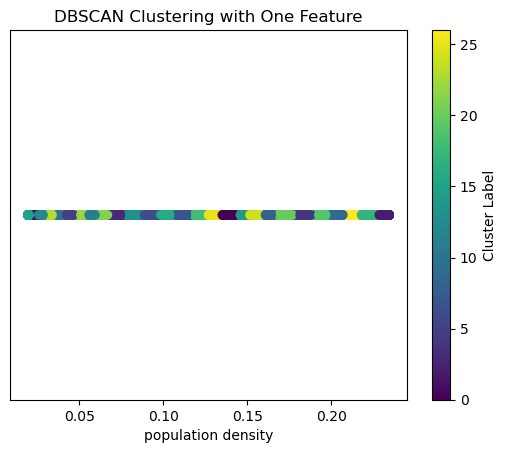

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(np.expand_dims(area_df["population_density"], 1))

# Step 3: Apply DBSCAN
kmeans = KMeans(n_clusters=27)  # Specify the number of clusters
kmeans.fit(X_scaled)

area_df["cluster"] = kmeans.labels_


df = area_df
plt.scatter(df['population_density'], np.zeros_like(df['population_density']), c=df['cluster'], cmap='viridis', marker='o')
plt.title('DBSCAN Clustering with One Feature')
plt.xlabel('population density')
plt.yticks([])  # Hide y-axis ticks since we have only one feature
plt.colorbar(label='Cluster Label')
plt.show()

In [14]:
area_df.tail()

,population_density,cluster
SSEC_CODE,,
350701,0.019472,15
350702,0.234255,2
350709,0.019472,15
350801,0.019472,15
359999,0.019472,15


In [15]:
area_df

,population_density,cluster
SSEC_CODE,,
10101,0.234255,2
10102,0.234255,2
10103,0.234255,2
10104,0.066129,21
10105,0.234255,2
...,...,...
350701,0.019472,15
350702,0.234255,2
350709,0.019472,15


In [16]:
# area_df = area_df.drop(columns=["population"])
area_df = area_df.rename_axis("area_id")

In [17]:
area_df.head()

,population_density,cluster
area_id,,
10101,0.234255,2
10102,0.234255,2
10103,0.234255,2
10104,0.066129,21
10105,0.234255,2


In [18]:
cluster_areas = area_df.groupby("cluster")["population_density"].mean().to_frame()

In [19]:
cluster_areas.head()

,population_density
cluster,
0,0.138801
1,0.023791
2,0.234195
3,0.072103
4,0.183133


In [20]:
estimated_popualtion = cluster_areas["population_density"] / np.max(cluster_areas["population_density"])**1.2
x = np.exp(estimated_popualtion - np.max(estimated_popualtion)) / np.sum(
    np.exp(estimated_popualtion - np.max(estimated_popualtion)), axis=0
)

areas_weights = x / np.max(x)

cluster_areas["weight"] = areas_weights
cluster_areas

,population_density,weight
cluster,,
0,0.138801,0.580110
1,0.023791,0.300879
2,0.234195,1.000000
3,0.072103,0.396425
4,0.183133,0.747159
5,0.044684,0.338990
6,0.092864,0.446302
7,0.111870,0.497446
8,0.162901,0.665664


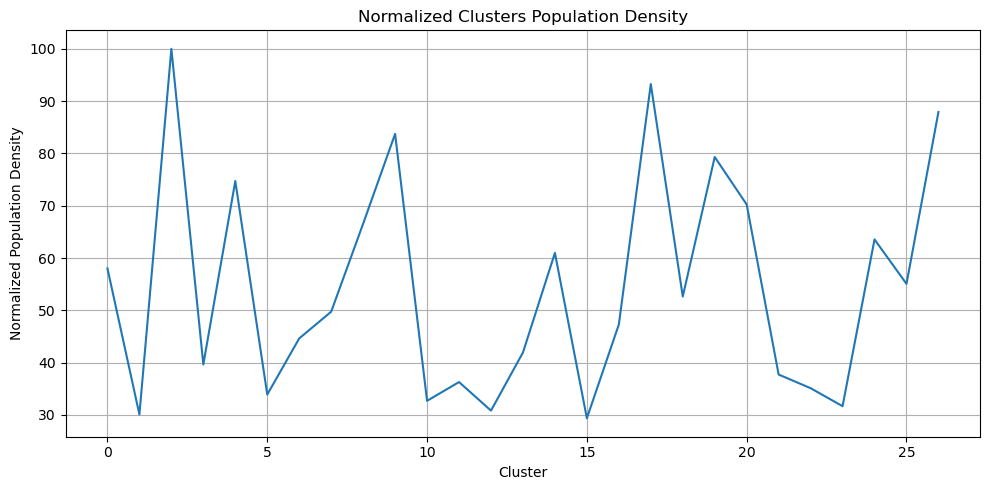

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(cluster_areas.index, cluster_areas['weight']*100 )
plt.title('Normalized Clusters Population Density')
plt.xlabel('Cluster')
plt.ylabel('Normalized Population Density')
plt.grid()

# Set x-ticks to show only some of the times
# tick_indices = df.index[:end:step]  # Show every 4th time point (adjust as needed)
# plt.xticks(cluster_areas['weight']*100, rotation=45)  # Rotate and align right

plt.tight_layout()
plt.show()

In [50]:
cluster_areas_df

,population_density,cluster
area_id,,
10101,0.234255,2
10102,0.234255,2
10103,0.234255,2
10104,0.066129,21
10105,0.234255,2
...,...,...
350701,0.019472,15
350702,0.234255,2
350709,0.019472,15


In [51]:
import geopandas as gpd
areas_gdf =areas_gdf
cluster_areas_df = area_df
cluster_areas_df.reset_index(inplace=True)
cluster_areas_df = cluster_areas_df.rename(columns={"area_id": "SSEC_CODE"})
areas_with_clusters = pd.merge(areas_gdf, cluster_areas_df, on='SSEC_CODE', suffixes=('_left', '_right'))
areas_with_clusters

,GOV_CODE,SEC_CODE,SSEC_CODE,SHAPE_Leng,SHAPE_Area,GOV_NAME_E,GOV_NAME_A,SEC_NAME_E,SEC_NAME_A,SSEC_NAME_,SSEC_NAM_1,geometry,population,population_density_left,population_density_right,cluster
0,28,2808,280801,12547.889894,9.361281e+06,Aswan Governorate,محافظه اسوان,New Aswan City,اسوان الجديده,mdynt aswan aljdyda,مدينة أسوان الجديدة,"POLYGON ((32.86417 24.18292, 32.86442 24.18183...",1154596.6,0.123337,0.123337,18
1,16,1607,160754,15185.387468,9.865280e+06,Gharbiya Governorate,محافظة الغربية,El-Mahalla El-Kubra,مركز المحله الكبرى,nmrt albsl,نمرة البصل,"POLYGON ((31.06371 31.06602, 31.06613 31.06578...",182352.4,0.019472,0.019472,15
2,17,1705,170525,7924.332176,2.336633e+06,Menoufia Governorate,محافظة المنوفية,Martyrs Center,مركز الشهداء,kfr dnshway,كفر دنشواي,"POLYGON ((30.85010 30.58893, 30.85025 30.58548...",104918.4,0.044902,0.044902,5
3,17,1711,171107,10282.252994,3.386741e+06,Menoufia Governorate,محافظة المنوفية,Sadat City and Center,مركز السادات,kfr daod,كفر داود,"MULTIPOLYGON (((30.83658 30.47675, 30.83655 30...",104399.6,0.030826,0.030826,23
4,17,1711,171103,15694.908721,5.659568e+06,Menoufia Governorate,محافظة المنوفية,Sadat City and Center,مركز السادات,altrana,الطرانة,"MULTIPOLYGON (((30.83929 30.44366, 30.83932 30...",104399.6,0.019472,0.019472,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5612,15,1501,150106,4814.622605,1.205519e+06,Kafr El-Sheikh Governorate,محافظه كفر الشيخ,Kafr El-Sheikh,قسم كفر الشيخ,aly mstfy alzwaoy,على مصطفى الزواوى,"POLYGON ((30.92297 31.12307, 30.92558 31.12122...",256547.0,0.212810,0.212810,26
5613,15,1501,150105,9549.815809,3.357297e+06,Kafr El-Sheikh Governorate,محافظه كفر الشيخ,Kafr El-Sheikh,قسم كفر الشيخ,aod alzwaoy,عوض الزواوى,"POLYGON ((30.94450 31.11903, 30.94438 31.11899...",256547.0,0.076415,0.076415,3
5614,15,1501,150103,7153.435833,8.463426e+05,Kafr El-Sheikh Governorate,محافظه كفر الشيخ,Kafr El-Sheikh,قسم كفر الشيخ,bdyralyoa,بديرعليوة,"POLYGON ((30.93439 31.12093, 30.93459 31.12096...",256547.0,0.234255,0.234255,2
5615,15,1501,150102,15154.158584,6.355187e+06,Kafr El-Sheikh Governorate,محافظه كفر الشيخ,Kafr El-Sheikh,قسم كفر الشيخ,almlhqat,الملحقات,"POLYGON ((30.96992 31.14869, 30.96951 31.14659...",256547.0,0.040368,0.040368,10


In [56]:
for row in areas_with_clusters.iterrows():
    print(row[1]["cluster"])

18
15
5
23
15
10
13
15
17
2
23
11
2
26
2
6
2
19
2
2
2
2
19
3
2
21
2
0
2
2
2
19
15
15
15
15
3
15
13
21
13
21
22
16
3
14
12
25
9
2
10
13
25
21
10
15
12
21
7
2
26
5
21
2
16
7
9
23
15
25
2
2
2
2
2
2
2
23
15
12
5
20
18
1
9
1
23
21
23
15
15
12
5
15
15
15
15
15
15
15
2
2
2
9
0
10
15
2
23
15
12
15
10
1
12
15
15
15
15
22
15
15
15
22
5
1
15
20
25
10
15
10
22
11
23
1
15
12
15
3
15
1
15
12
1
18
15
15
12
15
15
1
23
23
15
15
2
2
26
2
2
24
21
11
15
3
15
15
3
21
12
6
8
5
23
21
23
15
12
1
23
15
5
21
10
11
21
5
13
11
18
10
23
3
21
10
5
3
21
11
15
22
6
21
5
22
22
13
3
13
5
5
3
10
1
6
15
0
23
3
23
26
10
5
13
6
13
11
0
5
2
23
10
6
23
10
7
10
14
1
10
3
11
23
2
2
2
2
15
15
4
2
2
15
5
2
5
15
2
0
15
10
15
15
15
1
5
3
15
15
15
15
15
6
15
23
10
11
15
1
15
12
15
15
15
21
11
0
10
1
15
11
23
23
23
2
3
12
10
8
15
11
1
6
25
10
15
6
15
15
15
15
15
15
15
15
15
15
15
18
7
2
15
2
2
12
5
3
7
21
10
15
15
23
22
18
22
15
13
5
12
18
25
4
13
2
2
2
2
17
4
2
3
18
21
3
21
22
2
21
2
2
14
7
13
16
2
16
4
2
2
25
2
2
2
2
5
2
18
4
3
16

In [22]:
def get_multiplier_dict(gaussians_list, multiplier_range):
    gaussians = []
    for instance in multiplier_range:
        all_gaussian = 0.0
        magnify = False
        for guassian_params in gaussians_list:

            mean = guassian_params["mean"]
            if instance == mean:
                magnify = True

            std_dev = guassian_params["std_dev"]

            # Calculate Gaussian value and normalize to ensure max is 1
            gaussian_value = np.exp(-((instance - mean) ** 2) / (2 * std_dev**2))
            all_gaussian += gaussian_value

        if magnify:
            all_gaussian *= 1.05
        gaussians.append(all_gaussian)

    gaussians_normalizd = np.array(gaussians) / np.max(np.array(gaussians))

    return gaussians_normalizd


def get_month_gaussian(peak_instances):
    length = len(peak_instances)
    std = 1 / length * 24
    gaussian_list = list()
    for peak_instance in peak_instances:
        gaussian_list.append({"mean": peak_instance, "std_dev": std})

    return gaussian_list


def get_day_gaussian(peak_instances):
    length = len(peak_instances)
    std = 1 / length * 14
    gaussian_list = list()
    for peak_instance in peak_instances:
        gaussian_list.append({"mean": peak_instance, "std_dev": std})

    return gaussian_list


def get_hour_gaussian(peak_instances):
    length = len(peak_instances)
    std = 1 / length * 12
    gaussian_list = list()
    for peak_instance in peak_instances:
        gaussian_list.append({"mean": peak_instance, "std_dev": std})

    return gaussian_list


def get_year_multiplier_dict(start, end, freq, padding=0):
    multiplier_dict = dict()
    for i in range(start, end+1):
        if (i - (start + padding)) % freq == 0:
            multiplier_dict[i] = np.random.uniform(0.90, 1.0)
        else:
            multiplier_dict[i] = np.random.uniform(0.75, 0.85)

    return multiplier_dict


In [26]:
peak_months = [9, 10, 2, 3]
peak_days = [3, 4]
peak_hours = [9, 13, 14]

# start_year = 2010
# end_year = 2024
year_seasonality_freq = 4

complaints_count = 15

complaints_count_period = 15

In [121]:
import os
import copy
import random
import warnings

# Suppress FutureWarnings
warnings.simplefilter(action='ignore', category=FutureWarning)

AREA_CLUSTERS_DATA_DIR = "./area_clusters_dir"

os.makedirs(AREA_CLUSTERS_DATA_DIR, exist_ok=True)

month_multiplier = get_multiplier_dict(

    get_month_gaussian(peak_months), [i + 1 for i in range(12)]
)
day_multiplier = get_multiplier_dict(
    get_day_gaussian(peak_days), [i + 1 for i in range(7)]
)
hour_multiplier = get_multiplier_dict(
    get_hour_gaussian(peak_hours), [i for i in range(24)]
)

start_date = datetime(2024, 8, 1, 0, 0)
end_date = datetime(2024, 8, 3, 23, 59)
date_range = pd.date_range(start=start_date, end=end_date, freq='15T') 

num_qhrs = len(date_range)
num_clusters = len(cluster_areas)

areas_weights = np.expand_dims(cluster_areas["weight"].values, 0)

hour_multiplier = np.expand_dims(
    np.tile(np.expand_dims(hour_multiplier, 1).repeat(4, 1).flatten(),int(num_qhrs / 24 )), 1
)[:num_qhrs]
day_multiplier = np.roll(day_multiplier, -1 * start_date.day, axis=0)
day_multiplier = np.expand_dims(np.expand_dims(day_multiplier, 1).repeat(24 * 4, 1).flatten(), 1,
)
day_multiplier = day_multiplier[:num_qhrs]

month_multiplier = np.expand_dims(
    np.expand_dims(month_multiplier, 1)
    .repeat(24 * 4 * 31, 1)
    .flatten(),
    1,
)[:num_qhrs]

# Time delta of 15 minutes
qhr_time_delta = timedelta(minutes=complaints_count_period)

# create numpy array of size (num_time_periods, num_areas)
counts = np.ones((num_qhrs, num_clusters), dtype=np.int32) * int(complaints_count)
counts = counts * hour_multiplier * day_multiplier * month_multiplier * areas_weights

curr_counts = np.rint(counts).astype(np.int32)


complaints = []

for row in areas_with_clusters.iterrows():
    print(row[0])
    print(len(complaints))

    area_cluster = row[1]["cluster"]
    counts = curr_counts[:, area_cluster]
    for i, curr_time in enumerate(date_range[:-1]):
        complaints_to_generate = int(counts[i+1])
        make_anamoly = random.uniform(0, 1)
        if make_anamoly < 0.075:
            complaints_to_generate = random.randint(3,4)
        else:
            complaints_to_generate = random.randint(0,1)



        multi_point = areas_with_clusters.iloc[[row[0]]].sample_points(
                size=complaints_to_generate
            )
        for v in range(complaints_to_generate):
            complaints.append(
                {
                    "longitude": multi_point.get_coordinates().iloc[v].x,
                    "latitude": multi_point.get_coordinates().iloc[v].y,
                    "time": curr_time
                    + timedelta(
                        minutes=np.random.randint(0, 15),
                        seconds=np.random.randint(0, 60),
                    ),
                    "service_area_id": int(row[1]["SSEC_CODE"]),
                }
            )


0
0
1
187
2
376
3
573
4
762
5
946
6
1141
7
1365
8
1581
9
1765
10
1972
11
2193
12
2391
13
2615
14
2815
15
3035
16
3259
17
3467
18
3677
19
3879
20
4109
21
4299
22
4512
23
4750


KeyboardInterrupt: 

In [110]:
gov_gpd = gpd.GeoDataFrame.from_file("/home/mohamed/Mohamed/Vodafone_project/all_egypt_map_shpfile/shp_output_names/Governerates/Governerates.shp")


In [111]:
gov_gpd

,OBJECTID,GOV_CODE,SHAPE_Leng,SHAPE_Area,GOV_NAME_E,GOV_NAME_A,geometry
0,1,17,3.675955e+05,2.291259e+09,Menoufia Governorate,محافظة المنوفية,"POLYGON ((30.93811 30.74503, 30.94164 30.74394..."
1,2,25,6.215681e+05,1.650690e+10,Assiut Governorate,محافظه اسيوط,"POLYGON ((32.61100 27.72754, 32.64298 27.62446..."
2,3,2,4.725427e+05,2.365383e+09,Alexandria Governorate,محافظه الاسكندرية,"POLYGON ((30.08427 31.33214, 30.08428 31.33172..."
3,4,19,6.255065e+05,5.116252e+09,Ismailia Governorate,محافظه الاسماعلية,"MULTIPOLYGON (((32.17797 30.96293, 32.19302 30..."
4,5,31,2.652001e+06,1.227480e+11,Red Sea Governorate,محافظه البحر الاحمر,"POLYGON ((32.65113 29.07545, 32.64992 29.07236..."
5,6,18,7.067742e+05,1.139302e+10,Beheira Governorate,محافظه البحيرة,"POLYGON ((30.42256 31.37754, 30.43317 31.37565..."
6,7,21,1.345541e+06,3.658913e+10,Giza Governorate,محافظه الجيزه,"POLYGON ((30.87826 30.33994, 30.88228 30.33925..."
7,8,12,5.565520e+05,3.939328e+09,Dakahlia Governorate,محافظه الدقهلية,"POLYGON ((31.35766 31.53253, 31.40161 31.50720..."
8,9,4,5.931154e+05,9.098211e+09,Suez Governorate,محافظه السويس,"MULTIPOLYGON (((32.80320 30.19396, 32.80889 30..."
9,10,13,4.346279e+05,5.007182e+09,Sharqiyah Governorate,محافظه الشرقية,"POLYGON ((32.09733 31.13863, 32.11225 31.10583..."


In [122]:
import sys
sys.path.insert(0, "../")

In [123]:
from speech_geo_translation.utils.location_classifier import LocationClassifier

In [127]:
lc = LocationClassifier()

In [ ]:
'longitude': , 'latitude':

In [133]:
lc(( 29.450275259202158, 31.21400377264986 ))

{'gov_ar': 'محافظه الجيزه',
 'sec_ar': 26    العياط
 Name: SEC_NAME_A, dtype: object,
 'ssec_ar': 26    كفر جرزة
 Name: SSEC_NAM_1, dtype: object,
 'gov_en': 26    Giza Governorate
 Name: GOV_NAME_E, dtype: object,
 'sec_en': 26    El Ayat
 Name: SEC_NAME_E, dtype: object,
 'ssec_en': 26    kfr jrza
 Name: SSEC_NAME_, dtype: object,
 'gov_id': 21,
 'sec_id': 2112,
 'ssec_id': 211231}

In [140]:
start_date = datetime(2024, 7, 1, 0, 0)
end_date = datetime(2024, 7, 8, 23, 59)
date_range = pd.date_range(start=start_date, end=end_date, freq='15T') 
complaints = []
for row in gov_gpd.iterrows():
    print(row[0])
    print(len(complaints))


    for i, curr_time in enumerate(date_range[:-1]):
        make_anamoly = random.uniform(0, 1)
        if make_anamoly < 0.075:
            complaints_to_generate = random.randint(7,10)
        else:
            complaints_to_generate = random.randint(0,3)



        multi_point = areas_with_clusters.iloc[[row[0]]].sample_points(
                size=complaints_to_generate
            )
        for v in range(complaints_to_generate):
            long = multi_point.get_coordinates().iloc[v].x
            lat = multi_point.get_coordinates().iloc[v].y
            complaints.append(
                {
                    "longitude": long,
                    "latitude": lat,
                    "time": curr_time
                    + timedelta(
                        minutes=np.random.randint(0, 15),
                        seconds=np.random.randint(0, 60),
                    ),
                    "service_area_id": lc((lat, long))["ssec_id"],
                }
            )

0
0
1
1581
2
3088
3
4744
4
6345
5
7992
6
9589
7
11255
8
12848
9
14241
10
15717
11
17256
12
18874
13
20452
14
22009
15
23674
16
25244
17
26838
18
28361
19
29837
20
31391
21
32920
22
34391
23
36010
24
37583
25
39054
26
40563


In [141]:
len(complaints)

42128

In [142]:
len(date_range)


768

In [143]:
import sys
sys.path.insert(0, "../")

from speech_geo_translation.database.database_api import DatabaseAPI
from speech_geo_translation.database.models import Complaint


In [144]:
db = DatabaseAPI()

In [145]:
with db.engine.connect() as connection:
            # Inserting govs
            connection.execute(Complaint.__table__.insert(), complaints)
            connection.commit()

2024-10-14 22:37:59,611 INFO sqlalchemy.engine.Engine SELECT DATABASE()
2024-10-14 22:37:59,612 INFO sqlalchemy.engine.Engine [raw sql] {}
2024-10-14 22:38:00,344 INFO sqlalchemy.engine.Engine SELECT @@sql_mode
2024-10-14 22:38:00,345 INFO sqlalchemy.engine.Engine [raw sql] {}
2024-10-14 22:38:00,980 INFO sqlalchemy.engine.Engine SELECT @@lower_case_table_names
2024-10-14 22:38:00,980 INFO sqlalchemy.engine.Engine [raw sql] {}
2024-10-14 22:38:01,421 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2024-10-14 22:38:01,422 INFO sqlalchemy.engine.Engine INSERT INTO complaint (longitude, latitude, service_area_id, time) VALUES (%(longitude)s, %(latitude)s, %(service_area_id)s, %(time)s)
2024-10-14 22:38:01,423 INFO sqlalchemy.engine.Engine [generated in 0.23270s] [{'longitude': 32.846975069982996, 'latitude': 24.161379261810396, 'service_area_id': 280801, 'time': Timestamp('2024-07-01 00:07:27')}, {'longitude': 32.851019369909544, 'latitude': 24.16543634721254, 'service_area_id': 280801, 't

In [146]:
from sqlalchemy import create_engine, text
from sqlalchemy.orm import sessionmaker
from datetime import datetime, timedelta
import time

# Database configuration
engine = db.engine
Session = sessionmaker(bind=engine)

# Define MySQL functions with "FUN" suffix
CREATE_GOVS_FUNCTION = """
CREATE FUNCTION IF NOT EXISTS count_govs_qhr_FUN(execution_time DATETIME)
RETURNS INT
BEGIN
    DECLARE total_count INT;

    INSERT INTO govs_qhr_counts (gov_id, time, count, anamoly) 
    SELECT 
        S.governorate_id AS gov_id, 
        execution_time AS time, 
        COUNT(*) AS count,
        CASE 
            WHEN COUNT(*) > 6 THEN 'TRUE' 
            ELSE 'FALSE' 
        END AS anamoly
    FROM 
        service_area S 
    JOIN 
        complaint C ON C.service_area_id = S.id 
    WHERE 
        C.time <= execution_time
        AND C.time >= execution_time - INTERVAL 15 MINUTE 
    GROUP BY 
        S.governorate_id;

    SET total_count = ROW_COUNT();
    RETURN total_count;
END;
"""


def create_functions():
    with Session() as session:
        session.execute(text(CREATE_GOVS_FUNCTION))
        session.commit()

def call_function(func_name, execution_time):
    with Session() as session:
        session.execute(text(f"SELECT {func_name}(:execution_time)"), {'execution_time': execution_time})
        session.commit()

def main():
    # Create functions in the database
    create_functions()

    # Define the target date and the execution time for the functions
    start_time = datetime(2024, 7, 1, 0, 15)
    end_time = datetime(2024, 7, 9, 0, 0)

    current_time = start_time
    while current_time <= end_time:
        if current_time <= datetime.now():
            # Call the MySQL functions with the current time
            call_function('count_govs_qhr_FUN', current_time)
            print(f"Executed functions at {current_time}")

        # Wait for 15 minutes
        current_time += timedelta(minutes=15)


main()


2024-10-14 22:44:43,130 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2024-10-14 22:44:43,236 INFO sqlalchemy.engine.Engine 
CREATE FUNCTION IF NOT EXISTS count_govs_qhr_FUN(execution_time DATETIME)
RETURNS INT
BEGIN
    DECLARE total_count INT;

    INSERT INTO govs_qhr_counts (gov_id, time, count, anamoly) 
    SELECT 
        S.governorate_id AS gov_id, 
        execution_time AS time, 
        COUNT(*) AS count,
        CASE 
            WHEN COUNT(*) > 6 THEN 'TRUE' 
            ELSE 'FALSE' 
        END AS anamoly
    FROM 
        service_area S 
    JOIN 
        complaint C ON C.service_area_id = S.id 
    WHERE 
        C.time <= execution_time
        AND C.time >= execution_time - INTERVAL 15 MINUTE 
    GROUP BY 
        S.governorate_id;

    SET total_count = ROW_COUNT();
    RETURN total_count;
END;

2024-10-14 22:44:43,237 INFO sqlalchemy.engine.Engine [generated in 0.10569s] {}
2024-10-14 22:44:43,425 INFO sqlalchemy.engine.Engine COMMIT
2024-10-14 22:44:43,651 INFO 

In [23]:
start_date = datetime(2024, 8, 1)
end_date = datetime(2024, 8, 5, 23, 59)
date_range = pd.date_range(start=start_date, end=end_date, freq='15T') 

/tmp/ipykernel_6589/913128874.py:3: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  date_range = pd.date_range(start=start_date, end=end_date, freq='15T')


In [48]:
import pandas as pd
import os
AREA_CLUSTERS_DATA_DIR = "./area_clusters_dir"

In [49]:
df = pd.read_csv(os.path.join(AREA_CLUSTERS_DATA_DIR, "counts_6.csv"), names=["count"])

In [50]:
import matplotlib.pyplot as plt

In [51]:
df

,count
2010-01-01 00:00:00,0
2010-01-01 00:15:00,0
2010-01-01 00:30:00,0
2010-01-01 00:45:00,0
2010-01-01 01:00:00,0
...,...
2024-12-30 22:45:00,0
2024-12-30 23:00:00,0
2024-12-30 23:15:00,0
2024-12-30 23:30:00,0


In [52]:
end = 4000
step = end//5

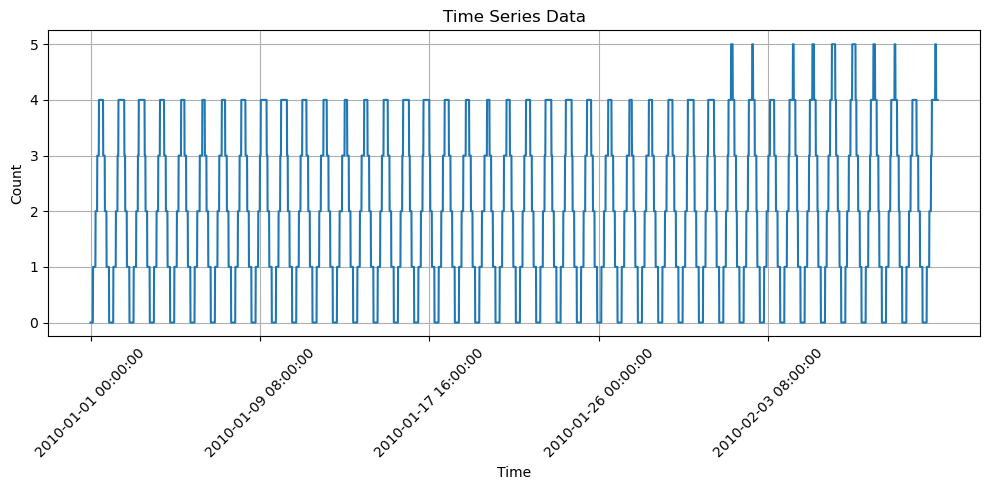

In [53]:
plt.figure(figsize=(10, 5))
plt.plot(df.index[:end], df['count'][:end])
plt.title('Time Series Data')
plt.xlabel('Time')
plt.ylabel('Count')
plt.grid()

# Set x-ticks to show only some of the times
tick_indices = df.index[:end:step]  # Show every 4th time point (adjust as needed)
plt.xticks(tick_indices, rotation=45)  # Rotate and align right

plt.tight_layout()
plt.show()

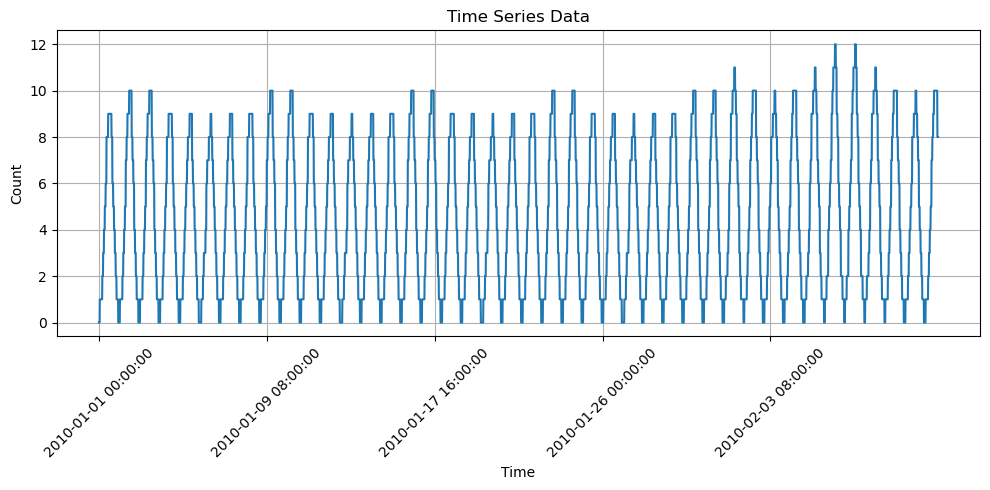

In [54]:
df = pd.read_csv(os.path.join(AREA_CLUSTERS_DATA_DIR, "counts_12.csv"), names=["count"])
plt.figure(figsize=(10, 5))
plt.plot(df.index[:end], df['count'][:end])
plt.title('Time Series Data')
plt.xlabel('Time')
plt.ylabel('Count')
plt.grid()

# Set x-ticks to show only some of the times
tick_indices = df.index[:end:step]  # Show every 4th time point (adjust as needed)
plt.xticks(tick_indices, rotation=45)  # Rotate and align right

plt.tight_layout()
plt.show()

In [55]:
import geopandas as gpd

In [56]:
areas_df =areas_gdf

In [57]:
cluster_areas_df = pd.read_csv("/home/mohamed/Mohamed/Vodafone_project/projects/app/files/anamoly_detection_files/areas_clusters.csv")

In [58]:
areas_df

,GOV_CODE,SEC_CODE,SSEC_CODE,SHAPE_Leng,SHAPE_Area,GOV_NAME_E,GOV_NAME_A,SEC_NAME_E,SEC_NAME_A,SSEC_NAME_,SSEC_NAM_1,geometry,population,population_density
0,28,2808,280801,12547.889894,9.361281e+06,Aswan Governorate,محافظه اسوان,New Aswan City,اسوان الجديده,mdynt aswan aljdyda,مدينة أسوان الجديدة,"POLYGON ((32.86417 24.18292, 32.86442 24.18183...",1154596.6,0.123337
1,16,1607,160754,15185.387468,9.865280e+06,Gharbiya Governorate,محافظة الغربية,El-Mahalla El-Kubra,مركز المحله الكبرى,nmrt albsl,نمرة البصل,"POLYGON ((31.06371 31.06602, 31.06613 31.06578...",182352.4,0.019472
2,17,1705,170525,7924.332176,2.336633e+06,Menoufia Governorate,محافظة المنوفية,Martyrs Center,مركز الشهداء,kfr dnshway,كفر دنشواي,"POLYGON ((30.85010 30.58893, 30.85025 30.58548...",104918.4,0.044902
3,17,1711,171107,10282.252994,3.386741e+06,Menoufia Governorate,محافظة المنوفية,Sadat City and Center,مركز السادات,kfr daod,كفر داود,"MULTIPOLYGON (((30.83658 30.47675, 30.83655 30...",104399.6,0.030826
4,17,1711,171103,15694.908721,5.659568e+06,Menoufia Governorate,محافظة المنوفية,Sadat City and Center,مركز السادات,altrana,الطرانة,"MULTIPOLYGON (((30.83929 30.44366, 30.83932 30...",104399.6,0.019472
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5612,15,1501,150106,4814.622605,1.205519e+06,Kafr El-Sheikh Governorate,محافظه كفر الشيخ,Kafr El-Sheikh,قسم كفر الشيخ,aly mstfy alzwaoy,على مصطفى الزواوى,"POLYGON ((30.92297 31.12307, 30.92558 31.12122...",256547.0,0.212810
5613,15,1501,150105,9549.815809,3.357297e+06,Kafr El-Sheikh Governorate,محافظه كفر الشيخ,Kafr El-Sheikh,قسم كفر الشيخ,aod alzwaoy,عوض الزواوى,"POLYGON ((30.94450 31.11903, 30.94438 31.11899...",256547.0,0.076415
5614,15,1501,150103,7153.435833,8.463426e+05,Kafr El-Sheikh Governorate,محافظه كفر الشيخ,Kafr El-Sheikh,قسم كفر الشيخ,bdyralyoa,بديرعليوة,"POLYGON ((30.93439 31.12093, 30.93459 31.12096...",256547.0,0.234255
5615,15,1501,150102,15154.158584,6.355187e+06,Kafr El-Sheikh Governorate,محافظه كفر الشيخ,Kafr El-Sheikh,قسم كفر الشيخ,almlhqat,الملحقات,"POLYGON ((30.96992 31.14869, 30.96951 31.14659...",256547.0,0.040368


In [59]:
cluster_areas_df

,area_id,population_density,cluster
0,10101,0.234255,0
1,10102,0.234255,0
2,10103,0.234255,0
3,10104,0.066129,16
4,10105,0.234255,0
...,...,...,...
5566,350701,0.019472,9
5567,350702,0.234255,0
5568,350709,0.019472,9
5569,350801,0.019472,9


In [60]:
cluster_areas_df = cluster_areas_df.rename(columns={"area_id": "SSEC_CODE"})
cluster_areas_df

,SSEC_CODE,population_density,cluster
0,10101,0.234255,0
1,10102,0.234255,0
2,10103,0.234255,0
3,10104,0.066129,16
4,10105,0.234255,0
...,...,...,...
5566,350701,0.019472,9
5567,350702,0.234255,0
5568,350709,0.019472,9
5569,350801,0.019472,9


In [61]:
x = pd.merge(areas_df, cluster_areas_df, on='SSEC_CODE', suffixes=('_left', '_right'))

In [62]:
type(x)

geopandas.geodataframe.GeoDataFrame

In [63]:
x

,GOV_CODE,SEC_CODE,SSEC_CODE,SHAPE_Leng,SHAPE_Area,GOV_NAME_E,GOV_NAME_A,SEC_NAME_E,SEC_NAME_A,SSEC_NAME_,SSEC_NAM_1,geometry,population,population_density_left,population_density_right,cluster
0,28,2808,280801,12547.889894,9.361281e+06,Aswan Governorate,محافظه اسوان,New Aswan City,اسوان الجديده,mdynt aswan aljdyda,مدينة أسوان الجديدة,"POLYGON ((32.86417 24.18292, 32.86442 24.18183...",1154596.6,0.123337,0.123337,11
1,16,1607,160754,15185.387468,9.865280e+06,Gharbiya Governorate,محافظة الغربية,El-Mahalla El-Kubra,مركز المحله الكبرى,nmrt albsl,نمرة البصل,"POLYGON ((31.06371 31.06602, 31.06613 31.06578...",182352.4,0.019472,0.019472,9
2,17,1705,170525,7924.332176,2.336633e+06,Menoufia Governorate,محافظة المنوفية,Martyrs Center,مركز الشهداء,kfr dnshway,كفر دنشواي,"POLYGON ((30.85010 30.58893, 30.85025 30.58548...",104918.4,0.044902,0.044902,23
3,17,1711,171107,10282.252994,3.386741e+06,Menoufia Governorate,محافظة المنوفية,Sadat City and Center,مركز السادات,kfr daod,كفر داود,"MULTIPOLYGON (((30.83658 30.47675, 30.83655 30...",104399.6,0.030826,0.030826,18
4,17,1711,171103,15694.908721,5.659568e+06,Menoufia Governorate,محافظة المنوفية,Sadat City and Center,مركز السادات,altrana,الطرانة,"MULTIPOLYGON (((30.83929 30.44366, 30.83932 30...",104399.6,0.019472,0.019472,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5612,15,1501,150106,4814.622605,1.205519e+06,Kafr El-Sheikh Governorate,محافظه كفر الشيخ,Kafr El-Sheikh,قسم كفر الشيخ,aly mstfy alzwaoy,على مصطفى الزواوى,"POLYGON ((30.92297 31.12307, 30.92558 31.12122...",256547.0,0.212810,0.212810,20
5613,15,1501,150105,9549.815809,3.357297e+06,Kafr El-Sheikh Governorate,محافظه كفر الشيخ,Kafr El-Sheikh,قسم كفر الشيخ,aod alzwaoy,عوض الزواوى,"POLYGON ((30.94450 31.11903, 30.94438 31.11899...",256547.0,0.076415,0.076415,6
5614,15,1501,150103,7153.435833,8.463426e+05,Kafr El-Sheikh Governorate,محافظه كفر الشيخ,Kafr El-Sheikh,قسم كفر الشيخ,bdyralyoa,بديرعليوة,"POLYGON ((30.93439 31.12093, 30.93459 31.12096...",256547.0,0.234255,0.234255,0
5615,15,1501,150102,15154.158584,6.355187e+06,Kafr El-Sheikh Governorate,محافظه كفر الشيخ,Kafr El-Sheikh,قسم كفر الشيخ,almlhqat,الملحقات,"POLYGON ((30.96992 31.14869, 30.96951 31.14659...",256547.0,0.040368,0.040368,7


In [64]:
areas_weights

array([[1.        , 0.30371859, 0.49328358, 0.68544816, 0.37169909,
        0.58185001, 0.40688749, 0.32514755, 0.80424002, 0.29381088,
        0.44750814, 0.5341451 , 0.92905993, 0.3472607 , 0.65053284,
        0.4245787 , 0.38871829, 0.75850901, 0.31397837, 0.55442072,
        0.86576619, 0.47179765, 0.61739774, 0.33645337, 0.72304223,
        0.35814518, 0.51559102]])

In [65]:
def add_weight(y):
    y["weight"] = areas_weights.flatten()[y["cluster"]]
    return y

x = x.apply(add_weight, axis=1)




In [77]:
x

,GOV_CODE,SEC_CODE,SSEC_CODE,SHAPE_Leng,SHAPE_Area,GOV_NAME_E,GOV_NAME_A,SEC_NAME_E,SEC_NAME_A,SSEC_NAME_,SSEC_NAM_1,geometry,population,population_density_left,population_density_right,cluster,weight
0,28,2808,280801,12547.889894,9.361281e+06,Aswan Governorate,محافظه اسوان,New Aswan City,اسوان الجديده,mdynt aswan aljdyda,مدينة أسوان الجديدة,"POLYGON ((32.86417 24.18292, 32.86442 24.18183...",1154596.6,0.123337,0.123337,11,0.534145
1,16,1607,160754,15185.387468,9.865280e+06,Gharbiya Governorate,محافظة الغربية,El-Mahalla El-Kubra,مركز المحله الكبرى,nmrt albsl,نمرة البصل,"POLYGON ((31.06371 31.06602, 31.06613 31.06578...",182352.4,0.019472,0.019472,9,0.293811
2,17,1705,170525,7924.332176,2.336633e+06,Menoufia Governorate,محافظة المنوفية,Martyrs Center,مركز الشهداء,kfr dnshway,كفر دنشواي,"POLYGON ((30.85010 30.58893, 30.85025 30.58548...",104918.4,0.044902,0.044902,23,0.336453
3,17,1711,171107,10282.252994,3.386741e+06,Menoufia Governorate,محافظة المنوفية,Sadat City and Center,مركز السادات,kfr daod,كفر داود,"MULTIPOLYGON (((30.83658 30.47675, 30.83655 30...",104399.6,0.030826,0.030826,18,0.313978
4,17,1711,171103,15694.908721,5.659568e+06,Menoufia Governorate,محافظة المنوفية,Sadat City and Center,مركز السادات,altrana,الطرانة,"MULTIPOLYGON (((30.83929 30.44366, 30.83932 30...",104399.6,0.019472,0.019472,9,0.293811
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5612,15,1501,150106,4814.622605,1.205519e+06,Kafr El-Sheikh Governorate,محافظه كفر الشيخ,Kafr El-Sheikh,قسم كفر الشيخ,aly mstfy alzwaoy,على مصطفى الزواوى,"POLYGON ((30.92297 31.12307, 30.92558 31.12122...",256547.0,0.212810,0.212810,20,0.865766
5613,15,1501,150105,9549.815809,3.357297e+06,Kafr El-Sheikh Governorate,محافظه كفر الشيخ,Kafr El-Sheikh,قسم كفر الشيخ,aod alzwaoy,عوض الزواوى,"POLYGON ((30.94450 31.11903, 30.94438 31.11899...",256547.0,0.076415,0.076415,6,0.406887
5614,15,1501,150103,7153.435833,8.463426e+05,Kafr El-Sheikh Governorate,محافظه كفر الشيخ,Kafr El-Sheikh,قسم كفر الشيخ,bdyralyoa,بديرعليوة,"POLYGON ((30.93439 31.12093, 30.93459 31.12096...",256547.0,0.234255,0.234255,0,1.000000
5615,15,1501,150102,15154.158584,6.355187e+06,Kafr El-Sheikh Governorate,محافظه كفر الشيخ,Kafr El-Sheikh,قسم كفر الشيخ,almlhqat,الملحقات,"POLYGON ((30.96992 31.14869, 30.96951 31.14659...",256547.0,0.040368,0.040368,7,0.325148


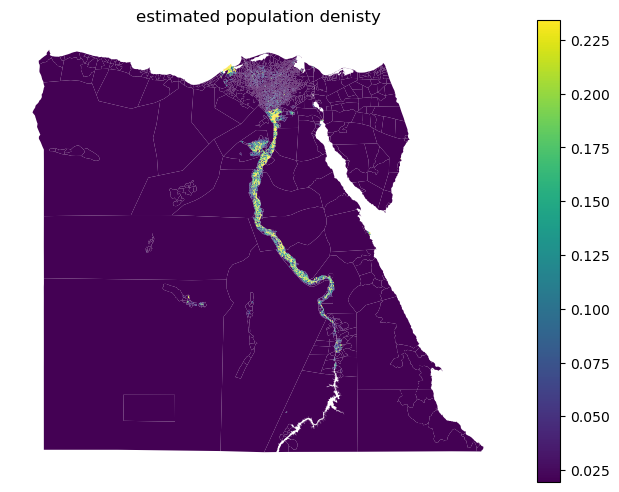

In [87]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


# Flatten the weights array and ensure it matches the number of geometries
# Map weights to the GeoDataFrame based on the cluster column
# x['weight'] = areas_weights.flatten()

# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Define a colormap
cmap = plt.get_cmap('viridis')

# Normalize the weights for color mapping
# norm = mcolors.Normalize(vmin=x['weight'].min(), vmax=x['weight'].max())

# Plot the GeoDataFrame with the weights as colors
areas_gdf.plot(column='population_density', cmap=cmap, ax=ax, legend=True,
     )

# Customize the plot
ax.set_title('estimated population denisty')
ax.set_axis_off()  # Turn off the axis

plt.show()

In [68]:
areas_weights

array([[1.        , 0.30371859, 0.49328358, 0.68544816, 0.37169909,
        0.58185001, 0.40688749, 0.32514755, 0.80424002, 0.29381088,
        0.44750814, 0.5341451 , 0.92905993, 0.3472607 , 0.65053284,
        0.4245787 , 0.38871829, 0.75850901, 0.31397837, 0.55442072,
        0.86576619, 0.47179765, 0.61739774, 0.33645337, 0.72304223,
        0.35814518, 0.51559102]])

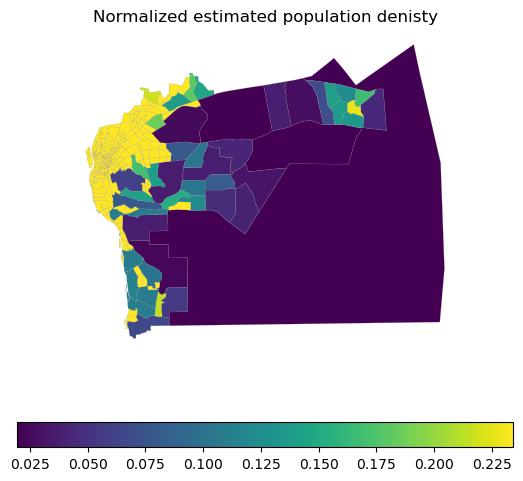

In [83]:
# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Define a colormap
cmap = plt.get_cmap('viridis')
# Plot
areas_gdf[ areas_gdf["GOV_CODE"] == 1].plot(column='population_density', cmap=cmap, ax=ax, legend=True,linewidth=0.1,edgecolor='gray',
         legend_kwds={'label': "",
                      'orientation': "horizontal",
                      'shrink': 0.8})

# Customize the plot
ax.set_title('Normalized estimated population denisty')
ax.set_axis_off()  # Turn off the axis

plt.show()

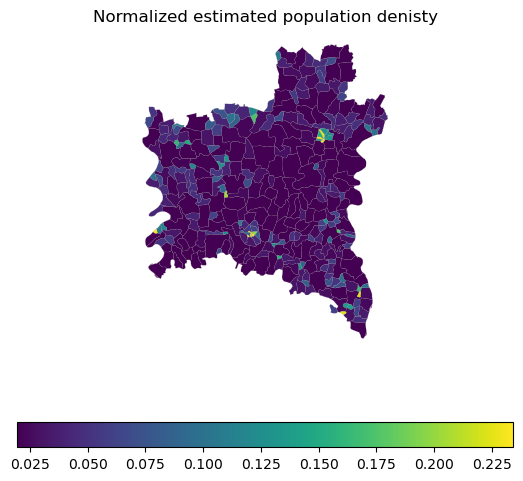

In [84]:
# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Define a colormap
cmap = plt.get_cmap('viridis')
# Plot
areas_gdf[ areas_gdf["GOV_CODE"] == 16].plot(column='population_density', cmap=cmap, ax=ax, legend=True,linewidth=0.1,edgecolor='gray',
         legend_kwds={'label': "",
                      'orientation': "horizontal",
                      'shrink': 0.8})

# Customize the plot
ax.set_title('Normalized estimated population denisty')
ax.set_axis_off()  # Turn off the axis

plt.show()

In [71]:
areas_weights

array([[1.        , 0.30371859, 0.49328358, 0.68544816, 0.37169909,
        0.58185001, 0.40688749, 0.32514755, 0.80424002, 0.29381088,
        0.44750814, 0.5341451 , 0.92905993, 0.3472607 , 0.65053284,
        0.4245787 , 0.38871829, 0.75850901, 0.31397837, 0.55442072,
        0.86576619, 0.47179765, 0.61739774, 0.33645337, 0.72304223,
        0.35814518, 0.51559102]])

In [70]:
areas_gdf

,GOV_CODE,SEC_CODE,SSEC_CODE,SHAPE_Leng,SHAPE_Area,GOV_NAME_E,GOV_NAME_A,SEC_NAME_E,SEC_NAME_A,SSEC_NAME_,SSEC_NAM_1,population
0,28,2808,280801,12547.889894,9.361281e+06,Aswan Governorate,محافظه اسوان,New Aswan City,اسوان الجديده,mdynt aswan aljdyda,مدينة أسوان الجديدة,797464
1,16,1607,160754,15185.387468,9.865280e+06,Gharbiya Governorate,محافظة الغربية,El-Mahalla El-Kubra,مركز المحله الكبرى,nmrt albsl,نمرة البصل,201427
2,17,1705,170525,7924.332176,2.336633e+06,Menoufia Governorate,محافظة المنوفية,Martyrs Center,مركز الشهداء,kfr dnshway,كفر دنشواي,77762
3,17,1711,171107,10282.252994,3.386741e+06,Menoufia Governorate,محافظة المنوفية,Sadat City and Center,مركز السادات,kfr daod,كفر داود,87568
4,17,1711,171103,15694.908721,5.659568e+06,Menoufia Governorate,محافظة المنوفية,Sadat City and Center,مركز السادات,altrana,الطرانة,97883
...,...,...,...,...,...,...,...,...,...,...,...,...
5612,15,1501,150106,4814.622605,1.205519e+06,Kafr El-Sheikh Governorate,محافظه كفر الشيخ,Kafr El-Sheikh,قسم كفر الشيخ,aly mstfy alzwaoy,على مصطفى الزواوى,320196
5613,15,1501,150105,9549.815809,3.357297e+06,Kafr El-Sheikh Governorate,محافظه كفر الشيخ,Kafr El-Sheikh,قسم كفر الشيخ,aod alzwaoy,عوض الزواوى,327371
5614,15,1501,150103,7153.435833,8.463426e+05,Kafr El-Sheikh Governorate,محافظه كفر الشيخ,Kafr El-Sheikh,قسم كفر الشيخ,bdyralyoa,بديرعليوة,326492
5615,15,1501,150102,15154.158584,6.355187e+06,Kafr El-Sheikh Governorate,محافظه كفر الشيخ,Kafr El-Sheikh,قسم كفر الشيخ,almlhqat,الملحقات,372641


In [1]:
import geopandas as gpd
import rasterio
import rioxarray
import numpy as np

# Load your GeoDataFrame (replace this with your actual data)
gdf = gpd.GeoDataFrame.from_file(SHAPEFILE)  # Replace with your shapefile path

# Load the population density raster file (GeoTIFF)
population_raster = rioxarray.open_rasterio('/home/mohamed/Mohamed/Vodafone_project/population estimation/egy_pd_2020_1km_UNadj.tif', masked=True)

# Ensure the GeoDataFrame is in the same CRS as the raster

# Ensure the GeoDataFrame is in the same CRS as the raster
gdf = gdf.to_crs(population_raster.rio.crs)

# Initialize lists to store results
total_population = []
areas_km2 = []

# Iterate over each polygon in the GeoDataFrame
for i, geometry in enumerate(gdf.geometry):
    print(i)
    # Clip the raster to the geometry
    try:
        clipped_raster = population_raster.rio.clip([geometry], gdf.crs, drop=True)
    except:
        total_pop = 0
    # Check if there are valid data points in the clipped raster
    if clipped_raster.size > 0:  # Ensure there's data in the clipped area
        # Calculate total population within the clipped area
        total_pop = np.nansum(clipped_raster.values)  # Use nansum to ignore NaN values
    else:
        total_pop = 0  # No valid data, set population to 0
    
    total_population.append(total_pop)
    
    # Calculate area in square kilometers
    area_km2 = geometry.area / 10**6  # Convert from m² to km²
    areas_km2.append(area_km2)

# Add results to GeoDataFrame
gdf['total_population'] = total_population
gdf['area_km2'] = areas_km2

# Calculate population density
gdf['population_density'] = gdf['total_population'] / gdf['area_km2']

# Display results
print(gdf[['total_population', 'area_km2', 'population_density']])

# Optional: Plotting results if needed
fig, ax = plt.subplots(figsize=(10, 10))
gdf[gdf["population_density"] < 1e14].plot(column='population_density', cmap='viridis', linewidth=0.8,
         edgecolor='black', ax=ax, legend=True,
         legend_kwds={'label': "Population Density (people/km²)",
                      'orientation': "horizontal"})
ax.set_title('Population Density by Area in Egypt')
plt.show()

NameError: name 'SHAPEFILE' is not defined

In [75]:
gdf['population_density'].max()

5.76859584376295e+16

In [77]:
gdf['population_density'].mean()


297327699424688.8

/home/mohamed/miniconda3/envs/torch/lib/python3.10/site-packages/geopandas/geodataframe.py:1459: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)


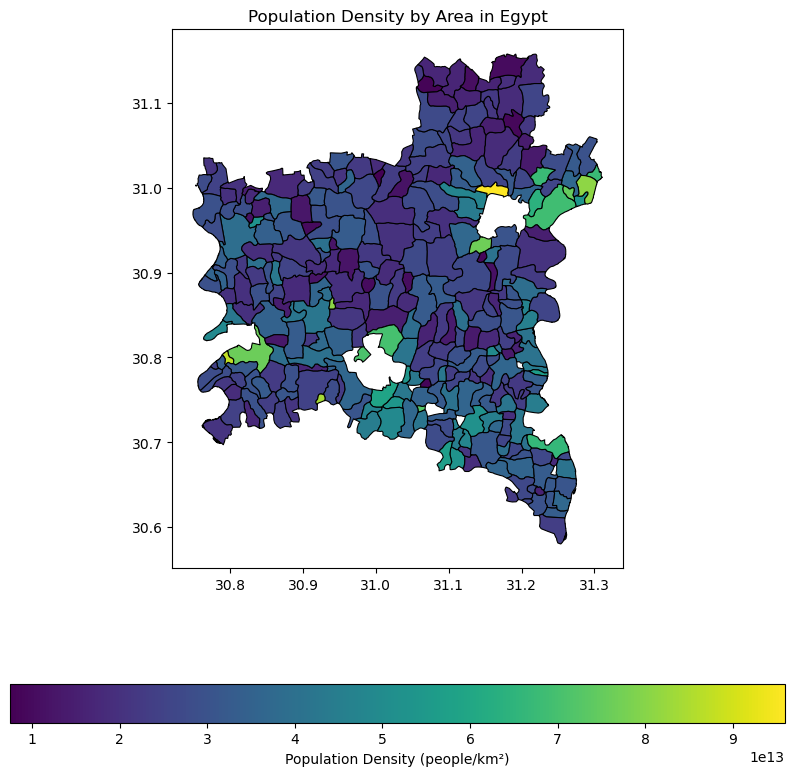

In [93]:

fig, ax = plt.subplots(figsize=(10, 10))
gdf[gdf["population_density"] < 1e14][gdf["GOV_CODE"] == 16].plot(column='population_density', cmap='viridis', linewidth=0.8,
         edgecolor='black', ax=ax, legend=True,
         legend_kwds={'label': "Population Density (people/km²)",
                      'orientation': "horizontal"})
ax.set_title('Population Density by Area in Egypt')
plt.show()

In [84]:
len(gdf['population_density'][gdf['population_density'] == 0])

0

In [83]:
mean_A = gdf['population_density'][gdf['population_density'] != 0].mean()

# Replace zeros in column 'A' with the calculated mean
gdf.loc[gdf['population_density'] == 0, 'population_density'] = mean_A

In [90]:
len(gdf['population_density'][gdf['population_density'] > 1e16])

34